In [289]:
! py -3.11 -m pip install chembl-webresource-client > nul 2>&1
! py -3.11 -m pip install rdkit > nul 2>&1
! py -3.11 -m pip install seaborn > nul 2>&1
! py -3.11 -m pip install scipy > nul 2>&1
! py -3.11 -m pip install padelpy > nul 2>&1
! py -3.11 -m pip install scikit-learn > nul 2>&1
! py -3.11 -m pip install lazypredict > nul 2>&1

# **Drug Design & Bioinformatics**

## **Partie 1: Collection des données**

### **1. Choisir un target**

**Target Choisi: Acetylcholinesterase**

In [326]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

pd.options.display.float_format = '{:.3f}'.format
pd.set_option('display.max_columns', None)

In [229]:
# Target search for coronavirus
target = new_client.target
target_query = target.search('acetylcholinesterase')
targets = pd.DataFrame.from_dict(target_query)
targets

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Drosophila melanogaster,Acetylcholinesterase,18.0,False,CHEMBL2242744,"[{'accession': 'P07140', 'component_descriptio...",SINGLE PROTEIN,7227
1,[],Homo sapiens,Acetylcholinesterase,16.0,False,CHEMBL220,"[{'accession': 'P22303', 'component_descriptio...",SINGLE PROTEIN,9606
2,[],Torpedo californica,Acetylcholinesterase,16.0,False,CHEMBL4780,"[{'accession': 'P04058', 'component_descriptio...",SINGLE PROTEIN,7787
3,[],Mus musculus,Acetylcholinesterase,16.0,False,CHEMBL3198,"[{'accession': 'P21836', 'component_descriptio...",SINGLE PROTEIN,10090
4,[],Rattus norvegicus,Acetylcholinesterase,16.0,False,CHEMBL3199,"[{'accession': 'P37136', 'component_descriptio...",SINGLE PROTEIN,10116
5,[],Electrophorus electricus,Acetylcholinesterase,16.0,False,CHEMBL4078,"[{'accession': 'O42275', 'component_descriptio...",SINGLE PROTEIN,8005
6,[],Bos taurus,Acetylcholinesterase,16.0,False,CHEMBL4768,"[{'accession': 'P23795', 'component_descriptio...",SINGLE PROTEIN,9913
7,[],Anopheles gambiae,Acetylcholinesterase,16.0,False,CHEMBL2046266,"[{'accession': 'Q869C3', 'component_descriptio...",SINGLE PROTEIN,7165
8,[],Bemisia tabaci,AChE2,16.0,False,CHEMBL2366409,"[{'accession': 'B3SST5', 'component_descriptio...",SINGLE PROTEIN,7038
9,[],Leptinotarsa decemlineata,Acetylcholinesterase,16.0,False,CHEMBL2366490,"[{'accession': 'Q27677', 'component_descriptio...",SINGLE PROTEIN,7539


In [230]:
selected_target = targets.target_chembl_id[1]
selected_target

'CHEMBL220'

### **2. Collecter données du Bioactivité du target**

In [231]:
# activity = new_client.activity
# res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")
# df = pd.DataFrame.from_dict(res)
# df

In [232]:
# df.to_csv(targets.pref_name[1] + "_" + targets.organism[1] + '_01_bioactivity_data_raw.csv', index=False)

### **3. Nettoyage des données**

In [233]:
df = pd.read_csv(targets.pref_name[1] + "_" + targets.organism[1] + '_01_bioactivity_data_raw.csv')

- **Suppression des valeurs nulles**

In [234]:
df2 = df[df.standard_value.notna()]
df2 = df2[df.canonical_smiles.notna()]
df2.head(5)

C:\Users\exe\AppData\Local\Temp\ipykernel_25948\801366148.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df2 = df2[df.canonical_smiles.notna()]


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,NaN,NaN,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '19.61', 'le': '0.36', 'lle': '3.32', ...",CHEMBL133897,NaN,CHEMBL133897,6.12,0,http://www.openphacts.org/units/Nanomolar,252547,=,1,1,=,NaN,IC50,nM,NaN,750.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.75
1,NaN,NaN,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '18.57', 'le': '0.38', 'lle': '2.45', ...",CHEMBL336398,NaN,CHEMBL336398,7.00,0,http://www.openphacts.org/units/Nanomolar,252533,=,1,1,=,NaN,IC50,nM,NaN,100.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.10
2,NaN,NaN,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,NaN,CHEMBL131588,NaN,CHEMBL131588,NaN,0,http://www.openphacts.org/units/Nanomolar,252530,>,1,1,>,NaN,IC50,nM,NaN,50000.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,50.00
3,NaN,NaN,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '16.11', 'le': '0.34', 'lle': '1.81', ...",CHEMBL130628,NaN,CHEMBL130628,6.52,0,http://www.openphacts.org/units/Nanomolar,252534,=,1,1,=,NaN,IC50,nM,NaN,300.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.30
4,NaN,NaN,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '17.60', 'le': '0.36', 'lle': '3.00', ...",CHEMBL130478,NaN,CHEMBL130478,6.10,0,http://www.openphacts.org/units/Nanomolar,252552,=,1,1,=,NaN,IC50,nM,NaN,800.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.80


In [235]:
df2.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='str')

- **Suppression des doublons**

In [236]:
df2_nr = df2.drop_duplicates(['canonical_smiles'])
df2_nr

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,bao_format,bao_label,canonical_smiles,data_validity_comment,data_validity_description,document_chembl_id,document_journal,document_year,ligand_efficiency,molecule_chembl_id,molecule_pref_name,parent_molecule_chembl_id,pchembl_value,potential_duplicate,qudt_units,record_id,relation,src_id,standard_flag,standard_relation,standard_text_value,standard_type,standard_units,standard_upper_value,standard_value,target_chembl_id,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,NaN,NaN,33969,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '19.61', 'le': '0.36', 'lle': '3.32', ...",CHEMBL133897,NaN,CHEMBL133897,6.12,0,http://www.openphacts.org/units/Nanomolar,252547,=,1,1,=,NaN,IC50,nM,NaN,750.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.75
1,NaN,NaN,37563,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '18.57', 'le': '0.38', 'lle': '2.45', ...",CHEMBL336398,NaN,CHEMBL336398,7.00,0,http://www.openphacts.org/units/Nanomolar,252533,=,1,1,=,NaN,IC50,nM,NaN,100.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.10
2,NaN,NaN,37565,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,NaN,CHEMBL131588,NaN,CHEMBL131588,NaN,0,http://www.openphacts.org/units/Nanomolar,252530,>,1,1,>,NaN,IC50,nM,NaN,50000.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,50.00
3,NaN,NaN,38902,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '16.11', 'le': '0.34', 'lle': '1.81', ...",CHEMBL130628,NaN,CHEMBL130628,6.52,0,http://www.openphacts.org/units/Nanomolar,252534,=,1,1,=,NaN,IC50,nM,NaN,300.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.30
4,NaN,NaN,41170,[],CHEMBL643384,Inhibitory concentration against acetylcholine...,B,NaN,NaN,BAO_0000190,BAO_0000357,single protein format,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,NaN,NaN,CHEMBL1148382,J Med Chem,2004.0,"{'bei': '17.60', 'le': '0.36', 'lle': '3.00', ...",CHEMBL130478,NaN,CHEMBL130478,6.10,0,http://www.openphacts.org/units/Nanomolar,252552,=,1,1,=,NaN,IC50,nM,NaN,800.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9724,NaN,643506,27216791,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,NaN,NaN,BAO_0000190,BAO_0000019,assay format,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,NaN,NaN,CHEMBL5726243,NaN,2017.0,"{'bei': '10.90', 'le': '0.27', 'lle': '1.39', ...",CHEMBL6054495,NaN,CHEMBL6054495,5.29,0,http://www.openphacts.org/units/Nanomolar,4256194,=,37,1,=,NaN,IC50,nM,NaN,5090.0,CHEMBL220,Homo sapiens,Acetylcholinesterase,9606,NaN,NaN,IC50,nM,UO_0000065,NaN,5090.00
9726,NaN,643508,27216797,[],CHEMBL5732338,Inhibition Assay: Acetylcholinesterase extract...,B,NaN,NaN,BAO_0000190,BAO_0000019,assay format,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,NaN,NaN,CHEMBL5726243,NaN,2017.0,"{'bei': '16.85', 'le': '0.34', 'lle': '1.51', ...",CHEMBL5755069,NaN,CHEMBL5755069,6.39,0,http://www.

In [237]:
selection = ['molecule_chembl_id','canonical_smiles','standard_value']
df3 = df2_nr[selection]
df3

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0
...,...,...,...
9724,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.0
9726,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.0
9727,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.0
9728,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.0


In [238]:
df3.iloc[4109]
df3.sort_values(by="standard_value")

,molecule_chembl_id,canonical_smiles,standard_value
7994,CHEMBL4780352,COc1cc2c(cc1OC)C(=O)/C(=C/c1ccc(OCCCCN[N+]3(C)...,0.000000e+00
7164,CHEMBL4443426,O=C(CCCCNc1c2c(nc3ccccc13)CCCC2)NCCc1c[nH]c2cc...,5.000000e-06
7186,CHEMBL4467284,S=C(CCCCCCCNc1c2c(nc3ccccc13)CCCC2)NCCc1c[nH]c...,5.000000e-06
7185,CHEMBL4469239,S=C(CCCCCNc1c2c(nc3ccccc13)CCCC2)NCCc1c[nH]c2c...,5.000000e-06
7184,CHEMBL4579667,O=C(CCCCCCCNc1c2c(nc3ccccc13)CCCC2)NCCc1c[nH]c...,5.000000e-06
...,...,...,...
752,CHEMBL334938,C[N+]1(C)CCO[C@@](O)(c2ccc(C#N)cc2)C1,1.158777e+07
5362,CHEMBL3597055,COC(=O)C1=C(Nc2ccc(F)cc2)C[C@@H](c2ccccc2)N(c2...,1.512000e+07
2703,CHEMBL1276534,O=C(NP(=O)(NN1CCOCC1)NN1CCOCC1)c1ccccc1,1.862000e+07
1895,CHEMBL51628,O=c1ccc2ccc(O)cc2o1,2.900000e+07


- **Corrections des 'smiles'**

In [239]:
df_no_smiles = df3.drop(columns='canonical_smiles')

In [240]:
smiles = []

for i in df3.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [241]:
df_clean_smiles = pd.concat([df_no_smiles.reset_index(drop=True),smiles.reset_index(drop=True)], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,canonical_smiles
0,CHEMBL133897,750.0,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1
1,CHEMBL336398,100.0,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1
2,CHEMBL131588,50000.0,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1
3,CHEMBL130628,300.0,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F
4,CHEMBL130478,800.0,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C
...,...,...,...
6893,CHEMBL6054495,5090.0,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1
6894,CHEMBL5755069,411.0,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl
6895,CHEMBL5791030,395.0,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1
6896,CHEMBL5799857,625.0,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl


In [242]:
df3.to_csv(targets.pref_name[1] + "_" + targets.organism[1] + '_01_bioactivity_data_preprocessed.csv', index=False)

### **4. Prétraitement**

- **Classer Bioactivité avec IC50**

In [243]:
bioactivity_threshold = []
for i in df3.standard_value:
  if float(i) >= 10000:
    bioactivity_threshold.append("inactive")
  elif float(i) <= 1000:
    bioactivity_threshold.append("active")
  else:
    bioactivity_threshold.append("intermediate")

In [244]:
bioactivity_class = pd.Series(bioactivity_threshold, name='class')
df5 = pd.concat(
    [df3.reset_index(drop=True), bioactivity_class.reset_index(drop=True)],
    axis=1
)
df5

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active
...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.0,intermediate
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.0,active
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.0,active
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.0,active


In [245]:
df5 = df5[df5['class'] != 'intermediate']

- **Limiter valeurs de IC50 à 100,000,000**

In [246]:
def norm_value(df):
    if "standard_value_norm" not in df.columns:
        df = df.copy()

        # convert safely to numeric
        df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")

        # cap values
        df["standard_value_norm"] = df["standard_value"].clip(upper=100000000)

        # drop original column
        df = df.drop(columns="standard_value", errors="ignore")

    return df


df5 = norm_value(df5)

- **Convertir de IC50 à pIC50**

In [247]:
import numpy as np

def pIC50(df):
    df = df.copy()
    
    df["standard_value_norm"] = pd.to_numeric(
        df["standard_value_norm"], errors="coerce"
    )
    df = df[df["standard_value_norm"] > 0]

    df["pIC50"] = -np.log10(df["standard_value_norm"] * 1e-9)

    df = df.drop(columns="standard_value_norm")

    return df

df5 = pIC50(df5)

In [248]:
df5

,molecule_chembl_id,canonical_smiles,class,pIC50
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,6.124939
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,7.000000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,4.301030
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,6.522879
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,6.096910
...,...,...,...,...
6890,CHEMBL6040839,COc1cc(N)c(I)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,6.517126
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,6.386158
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,6.403403
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,6.204120


In [249]:
df5.to_csv(targets.pref_name[1] + "_" + targets.organism[1] + '_01_bioactivity_data_curated.csv', index=False)

## **Partie 2: Analyse Exploratoire**

In [250]:
!if not exist sascorer.py wget https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
!if not exist fpscores.pkl.gz wget https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz

### **1. Calculer les Descripteurs de Lipinski**

In [251]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, AllChem, rdMolDescriptors
from rdkit.Chem.rdMolDescriptors import CalcExactMolWt
from sascorer import calculateScore

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)
       
    baseData= np.arange(1,1)
    i=0  
    for mol in moldata:     
           
        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
        SaScore = calculateScore(mol)
        qed = QED.qed(mol)
        RB = Descriptors.NumRotatableBonds(mol)
        AP = Descriptors.FractionCSP3(mol)
        logS = 0.16 - 0.63*desc_MolLogP - 0.0062*desc_MolWt + 0.066*RB - 0.74*AP
        tpsa = Descriptors.TPSA(mol)
        mol_volume = rdMolDescriptors.CalcExactMolWt(mol)
        n_atoms = mol.GetNumAtoms()
        n_bonds = mol.GetNumBonds()
        aromatic_proportion = rdMolDescriptors.CalcNumAromaticRings(mol) / mol.GetNumAtoms()
           
        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors,
                        SaScore,
                        qed,
                        RB,
                        AP,
                        logS,
                        tpsa,
                        mol_volume,
                        n_atoms,
                        n_bonds,
                        aromatic_proportion])   
    
        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1  
        
        print(f"molecule num: {i} is completed.")    
     
    columnNames = [
        "MW",
        "LogP",
        "NumHDonors",
        "NumHAcceptors",
        "SA_Score",
        "QED",
        "Rotatable_Bonds",
        "Aromatic_Proportion",
        "logS",
        "TPSA",
        "Molecular_Volume",
        "Num_Atoms",
        "Num_Bonds",
        "Aromatic_Proportion"
    ] 
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)
    
    return descriptors

In [252]:
df_lipinski = lipinski(df5.canonical_smiles)
df_lipinski

molecule num: 1 is completed.
molecule num: 2 is completed.
molecule num: 3 is completed.
molecule num: 4 is completed.
molecule num: 5 is completed.
molecule num: 6 is completed.
molecule num: 7 is completed.
molecule num: 8 is completed.
molecule num: 9 is completed.
molecule num: 10 is completed.
molecule num: 11 is completed.
molecule num: 12 is completed.
molecule num: 13 is completed.
molecule num: 14 is completed.
molecule num: 15 is completed.
molecule num: 16 is completed.
molecule num: 17 is completed.
molecule num: 18 is completed.
molecule num: 19 is completed.
molecule num: 20 is completed.
molecule num: 21 is completed.
molecule num: 22 is completed.
molecule num: 23 is completed.
molecule num: 24 is completed.
molecule num: 25 is completed.
molecule num: 26 is completed.
molecule num: 27 is completed.
molecule num: 28 is completed.
molecule num: 29 is completed.
molecule num: 30 is completed.
molecule num: 31 is completed.
molecule num: 32 is completed.
molecule num: 33 

,MW,LogP,NumHDonors,NumHAcceptors,SA_Score,QED,Rotatable_Bonds,Aromatic_Proportion,logS,TPSA,Molecular_Volume,Num_Atoms,Num_Bonds,Aromatic_Proportion
0,312.325,2.8032,0.0,5.0,2.202477,0.699960,6.0,0.176471,-3.277019,66.49,312.111007,23.0,25.0,0.130435
1,376.913,4.5546,0.0,4.0,2.500920,0.734047,4.0,0.500000,-5.152259,51.02,376.112460,25.0,28.0,0.080000
2,426.851,5.3574,0.0,4.0,2.575242,0.527034,4.0,0.166667,-5.720972,51.02,426.052894,28.0,30.0,0.107143
3,404.845,4.7069,0.0,4.0,2.611889,0.695219,3.0,0.437500,-5.441136,51.02,404.068544,26.0,28.0,0.076923
4,346.334,3.0953,0.0,5.0,2.566177,0.799502,3.0,0.307692,-3.967002,60.25,346.071131,23.0,24.0,0.086957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5129,484.422,5.1372,1.0,4.0,2.528399,0.331076,7.0,0.681818,-6.122398,55.56,484.158676,27.0,29.0,0.037037
5130,378.944,4.8830,2.0,4.0,2.437482,0.546289,6.0,0.666667,-5.363076,66.56,378.207406,26.0,28.0,0.038462
5131,406.998,5.5761,1.0,4.0,2.407162,0.452109,8.0,0.695652,-5.863113,55.56,406.238706,28.0,30.0,0.035714
5132,424.988,5.5257,1.0,4.0,2.596644,0.418176,9.0,0.695652,-5.876899,55.56,424.229284,29.0,31.0,0.034483


In [253]:
df_combined = pd.concat([df5.reset_index(drop=True),df_lipinski.reset_index(drop=True)], axis=1)
df_combined

,molecule_chembl_id,canonical_smiles,class,pIC50,MW,LogP,NumHDonors,NumHAcceptors,SA_Score,QED,Rotatable_Bonds,Aromatic_Proportion,logS,TPSA,Molecular_Volume,Num_Atoms,Num_Bonds,Aromatic_Proportion
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,6.124939,312.325,2.8032,0.0,5.0,2.202477,0.699960,6.0,0.176471,-3.277019,66.49,312.111007,23.0,25.0,0.130435
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,7.000000,376.913,4.5546,0.0,4.0,2.500920,0.734047,4.0,0.500000,-5.152259,51.02,376.112460,25.0,28.0,0.080000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,4.301030,426.851,5.3574,0.0,4.0,2.575242,0.527034,4.0,0.166667,-5.720972,51.02,426.052894,28.0,30.0,0.107143
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,6.522879,404.845,4.7069,0.0,4.0,2.611889,0.695219,3.0,0.437500,-5.441136,51.02,404.068544,26.0,28.0,0.076923
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,6.096910,346.334,3.0953,0.0,5.0,2.566177,0.799502,3.0,0.307692,-3.967002,60.25,346.071131,23.0,24.0,0.086957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5129,CHEMBL6040839,COc1cc(N)c(I)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,6.517126,484.422,5.1372,1.0,4.0,2.528399,0.331076,7.0,0.681818,-6.122398,55.56,484.158676,27.0,29.0,0.037037
5130,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,6.386158,378.944,4.8830,2.0,4.0,2.437482,0.546289,6.0,0.666667,-5.363076,66.56,378.207406,26.0,28.0,0.038462
5131,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,6.403403,406.998,5.5761,1.0,4.0,2.407162,0.452109,8.0,0.695652,-5.863113,55.56,406.238706,28.0,30.0,0.035714
5132,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,6.204120,424.988,5.5257,1.0,4.0,2.596644,0.418176,9.0,0.695652,-5.876899,55.56,424.229284,29.0,31.0,0.034483


In [254]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

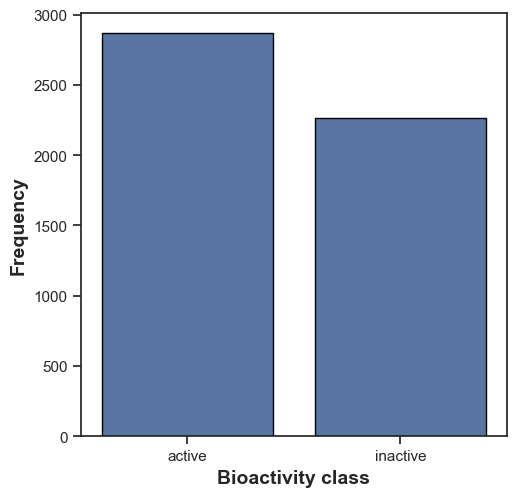

In [255]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_combined, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

In [256]:
df_combined.sort_values(by="pIC50")

,molecule_chembl_id,canonical_smiles,class,pIC50,MW,LogP,NumHDonors,NumHAcceptors,SA_Score,QED,Rotatable_Bonds,Aromatic_Proportion,logS,TPSA,Molecular_Volume,Num_Atoms,Num_Bonds,Aromatic_Proportion
802,CHEMBL371798,CN(CCCCCCCOc1ccc2c(c1)O/C(=C\c1cccc3ccccc13)C2...,inactive,1.304518,521.657,7.62290,1.0,5.0,2.577461,0.153465,12.0,0.264706,-7.280583,59.00,521.256609,39.0,43.0,0.102564
1098,CHEMBL51628,O=c1ccc2ccc(O)cc2o1,inactive,1.537602,162.144,1.49860,1.0,3.0,1.997904,0.596945,0.0,0.000000,-1.789411,50.44,162.031694,12.0,13.0,0.166667
1622,CHEMBL1276534,O=C(NP(=O)(NN1CCOCC1)NN1CCOCC1)c1ccccc1,inactive,1.730020,369.362,0.19810,3.0,6.0,2.991136,0.612403,6.0,0.533333,-2.253514,95.17,369.156591,25.0,27.0,0.040000
2667,CHEMBL3597055,COC(=O)C1=C(Nc2ccc(F)cc2)C[C@@H](c2ccccc2)N(c2...,inactive,1.820448,496.557,7.19670,1.0,4.0,3.220257,0.286825,6.0,0.129032,-7.152058,41.57,496.196235,37.0,41.0,0.108108
464,CHEMBL334938,C[N+]1(C)CCO[C@@](O)(c2ccc(C#N)cc2)C1,inactive,1.936000,233.291,0.80998,1.0,3.0,3.713981,0.730274,1.0,0.461538,-2.072230,53.25,233.128454,17.0,18.0,0.058824
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3630,CHEMBL199748,COc1ccc2[nH]cc(CCNC(=O)CCCCCNc3c4c(nc5cc(Cl)cc...,active,14.301030,519.089,6.58810,3.0,4.0,2.609106,0.195663,11.0,0.400000,-6.778855,79.04,518.244854,37.0,41.0,0.108108
3631,CHEMBL200008,COc1ccc2[nH]cc(CCNC(=O)CCCCCNc3c4c(nc5cccc(Cl)...,active,14.301030,519.089,6.58810,3.0,4.0,2.661016,0.195663,11.0,0.400000,-6.778855,79.04,518.244854,37.0,41.0,0.108108
3632,CHEMBL4468781,COc1ccc2[nH]cc(CCNC(=O)CCCCCNc3c4c(nc5cc(Cl)cc...,active,14.301030,553.534,7.24150,3.0,4.0,2.752175,0.171171,11.0,0.400000,-7.404056,79.04,552.205882,38.0,42.0,0.105263
3634,CHEMBL4469239,S=C(CCCCCNc1c2c(nc3ccccc13)CCCC2)NCCc1c[nH]c2c...,active,14.301030,470.686,6.72690,3.0,3.0,2.643360,0.177698,10.0,0.379310,-6.616890,52.74,470.250418,34.0,38.0,0.117647


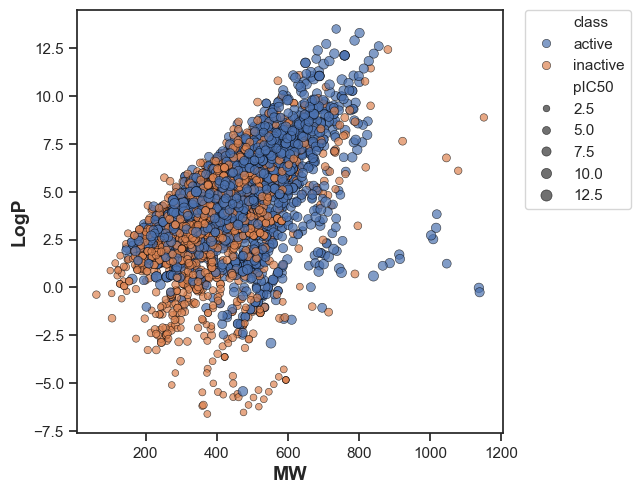

In [257]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_combined, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

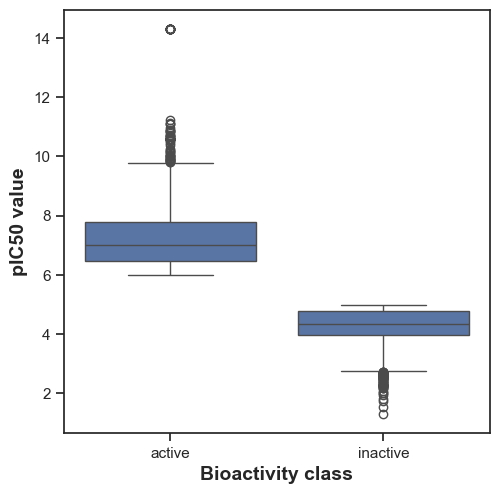

In [258]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_combined)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [259]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_combined[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_combined[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'
  
  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [260]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,6498285.0,0.0,0.05,Different distribution (reject H0)


#### **MW**

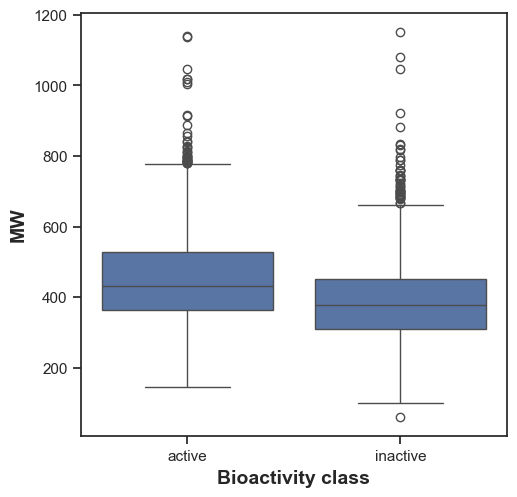

In [261]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_combined)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [262]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,4191218.0,2.203624e-71,0.05,Different distribution (reject H0)


#### **LogP**

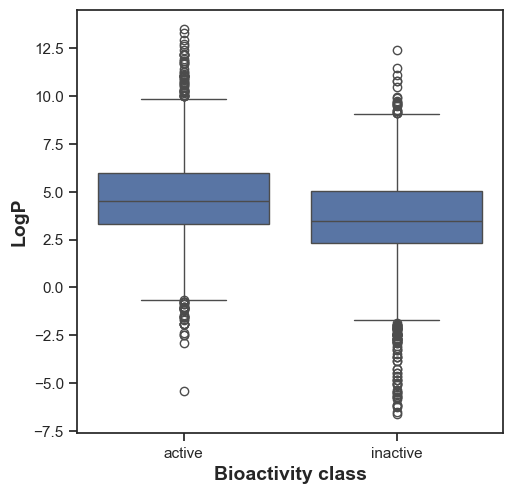

In [263]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_combined)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [264]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,4142972.5,1.916867e-64,0.05,Different distribution (reject H0)


#### **NumHDonors**

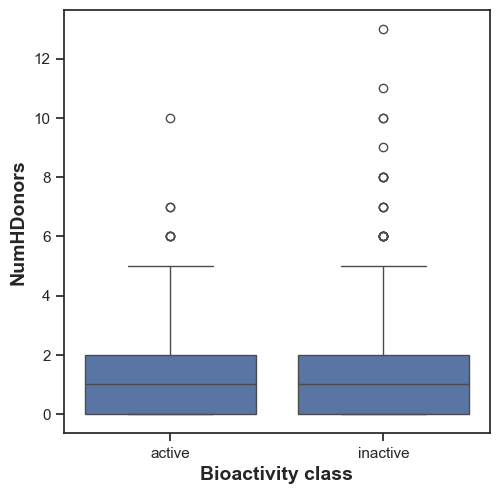

In [265]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data = df_combined)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [266]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,3694297.0,8.857326e-19,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

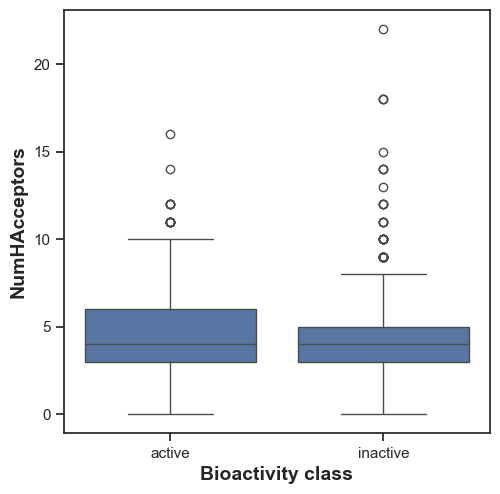

In [267]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_combined)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

### **2. Interprétation des résultats statistiques**

## **Partie 3: Calculations des descripteurs**

In [268]:
df_combined

,molecule_chembl_id,canonical_smiles,class,pIC50,MW,LogP,NumHDonors,NumHAcceptors,SA_Score,QED,Rotatable_Bonds,Aromatic_Proportion,logS,TPSA,Molecular_Volume,Num_Atoms,Num_Bonds,Aromatic_Proportion
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,active,6.124939,312.325,2.8032,0.0,5.0,2.202477,0.699960,6.0,0.176471,-3.277019,66.49,312.111007,23.0,25.0,0.130435
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,active,7.000000,376.913,4.5546,0.0,4.0,2.500920,0.734047,4.0,0.500000,-5.152259,51.02,376.112460,25.0,28.0,0.080000
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,inactive,4.301030,426.851,5.3574,0.0,4.0,2.575242,0.527034,4.0,0.166667,-5.720972,51.02,426.052894,28.0,30.0,0.107143
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,active,6.522879,404.845,4.7069,0.0,4.0,2.611889,0.695219,3.0,0.437500,-5.441136,51.02,404.068544,26.0,28.0,0.076923
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,active,6.096910,346.334,3.0953,0.0,5.0,2.566177,0.799502,3.0,0.307692,-3.967002,60.25,346.071131,23.0,24.0,0.086957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5129,CHEMBL6040839,COc1cc(N)c(I)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,6.517126,484.422,5.1372,1.0,4.0,2.528399,0.331076,7.0,0.681818,-6.122398,55.56,484.158676,27.0,29.0,0.037037
5130,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,6.386158,378.944,4.8830,2.0,4.0,2.437482,0.546289,6.0,0.666667,-5.363076,66.56,378.207406,26.0,28.0,0.038462
5131,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,active,6.403403,406.998,5.5761,1.0,4.0,2.407162,0.452109,8.0,0.695652,-5.863113,55.56,406.238706,28.0,30.0,0.035714
5132,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,active,6.204120,424.988,5.5257,1.0,4.0,2.596644,0.418176,9.0,0.695652,-5.876899,55.56,424.229284,29.0,31.0,0.034483


### **1. Calculer Descripteurs PaDEL**

In [269]:
! wget https://github.com/dataprofessor/bioinformatics/raw/master/padel.zip
! wget https://github.com/dataprofessor/bioinformatics/raw/master/padel.sh

--2026-04-20 15:55:28--  https://github.com/dataprofessor/bioinformatics/raw/master/padel.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-20 15:55:29 ERROR 404: Not Found.

--2026-04-20 15:55:29--  https://github.com/dataprofessor/bioinformatics/raw/master/padel.sh
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-20 15:55:29 ERROR 404: Not Found.



In [270]:
from padelpy import padeldescriptor
import os

def generate_fingerprint_fast(df, output_file='descriptors.csv'):
    df[['canonical_smiles', 'molecule_chembl_id']].to_csv('molecules.smi', sep='\t', index=False, header=False)
    print("Starting batch processing...")
    padeldescriptor(
        mol_dir='molecules.smi', 
        d_file=output_file,
        fingerprints=True, 
        removesalt=True,
        log=True
    )
    desc_data = pd.read_csv(output_file).drop(columns="Name")
    output_data = pd.concat([df.reset_index(drop=True), desc_data], axis=1)

    os.remove('molecules.smi')
    
    return output_data

In [271]:
df_combined = generate_fingerprint_fast(df_combined)

Starting batch processing...


In [272]:
df_combined

,molecule_chembl_id,canonical_smiles,class,pIC50,MW,LogP,NumHDonors,NumHAcceptors,SA_Score,QED,Rotatable_Bonds,Aromatic_Proportion,logS,TPSA,Molecular_Volume,Num_Atoms,Num_Bonds,Aromatic_Proportion,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,PubchemFP10,PubchemFP11,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP17,PubchemFP18,PubchemFP19,PubchemFP20,PubchemFP21,PubchemFP22,PubchemFP23,PubchemFP24,PubchemFP25,PubchemFP26,PubchemFP27,PubchemFP28,PubchemFP29,PubchemFP30,PubchemFP31,PubchemFP32,PubchemFP33,PubchemFP34,PubchemFP35,PubchemFP36,PubchemFP37,PubchemFP38,PubchemFP39,PubchemFP40,PubchemFP41,PubchemFP42,PubchemFP43,PubchemFP44,PubchemFP45,PubchemFP46,PubchemFP47,PubchemFP48,PubchemFP49,PubchemFP50,PubchemFP51,PubchemFP52,PubchemFP53,PubchemFP54,PubchemFP55,PubchemFP56,PubchemFP57,PubchemFP58,PubchemFP59,PubchemFP60,PubchemFP61,PubchemFP62,PubchemFP63,PubchemFP64,PubchemFP65,PubchemFP66,PubchemFP67,PubchemFP68,PubchemFP69,PubchemFP70,PubchemFP71,PubchemFP72,PubchemFP73,PubchemFP74,PubchemFP75,PubchemFP76,PubchemFP77,PubchemFP78,PubchemFP79,PubchemFP80,PubchemFP81,PubchemFP82,PubchemFP83,PubchemFP84,PubchemFP85,PubchemFP86,PubchemFP87,PubchemFP88,PubchemFP89,PubchemFP90,PubchemFP91,PubchemFP92,PubchemFP93,PubchemFP94,PubchemFP95,PubchemFP96,PubchemFP97,PubchemFP98,PubchemFP99,PubchemFP100,PubchemFP101,PubchemFP102,PubchemFP103,PubchemFP104,PubchemFP105,PubchemFP106,PubchemFP107,PubchemFP108,PubchemFP109,PubchemFP110,PubchemFP111,PubchemFP112,PubchemFP113,PubchemFP114,PubchemFP115,PubchemFP116,PubchemFP117,PubchemFP118,PubchemFP119,PubchemFP120,PubchemFP121,PubchemFP122,PubchemFP123,PubchemFP124,PubchemFP125,PubchemFP126,PubchemFP127,PubchemFP128,PubchemFP129,PubchemFP130,PubchemFP131,PubchemFP132,PubchemFP133,PubchemFP134,PubchemFP135,PubchemFP136,PubchemFP137,PubchemFP138,PubchemFP139,PubchemFP140,PubchemFP141,PubchemFP142,PubchemFP143,PubchemFP144,PubchemFP145,PubchemFP146,PubchemFP147,PubchemFP148,PubchemFP149,PubchemFP150,PubchemFP151,PubchemFP152,PubchemFP153,PubchemFP154,PubchemFP155,PubchemFP156,PubchemFP157,PubchemFP158,PubchemFP159,PubchemFP160,PubchemFP161,PubchemFP162,PubchemFP163,PubchemFP164,PubchemFP165,PubchemFP166,PubchemFP167,PubchemFP168,PubchemFP169,PubchemFP170,PubchemFP171,PubchemFP172,PubchemFP173,PubchemFP174,PubchemFP175,PubchemFP176,PubchemFP177,PubchemFP178,PubchemFP179,PubchemFP180,PubchemFP181,PubchemFP182,PubchemFP183,PubchemFP184,PubchemFP185,PubchemFP186,PubchemFP187,PubchemFP188,PubchemFP189,PubchemFP190,PubchemFP191,PubchemFP192,PubchemFP193,PubchemFP194,PubchemFP195,PubchemFP196,PubchemFP197,PubchemFP198,PubchemFP199,PubchemFP200,PubchemFP201,PubchemFP202,PubchemFP203,PubchemFP204,PubchemFP205,PubchemFP206,PubchemFP207,PubchemFP208,PubchemFP209,PubchemFP210,PubchemFP211,PubchemFP212,PubchemFP213,PubchemFP214,PubchemFP215,PubchemFP216,PubchemFP217,PubchemFP218,PubchemFP219,PubchemFP220,PubchemFP221,PubchemFP222,PubchemFP223,PubchemFP224,PubchemFP225,PubchemFP226,PubchemFP227,PubchemFP228,PubchemFP229,PubchemFP230,PubchemFP231,PubchemFP232,PubchemFP233,PubchemFP234,PubchemFP235,PubchemFP236,PubchemFP237,PubchemFP238,PubchemFP239,PubchemFP240,PubchemFP241,PubchemFP242,PubchemFP243,PubchemFP244,PubchemFP245,PubchemFP246,PubchemFP247,PubchemFP248,PubchemFP249,PubchemFP250,PubchemFP251,PubchemFP252,PubchemFP253,PubchemFP254,PubchemFP255,PubchemFP256,PubchemFP257,PubchemFP258,PubchemFP259,PubchemFP260,PubchemFP261,PubchemFP262,PubchemFP263,PubchemFP264,PubchemFP265,PubchemFP266,PubchemFP267,PubchemFP268,PubchemFP269,PubchemFP270,PubchemFP271,PubchemFP272,PubchemFP273,PubchemFP274,PubchemFP275,PubchemFP276,PubchemFP277,PubchemFP278,PubchemFP279,PubchemFP280,PubchemFP281,PubchemFP282,PubchemFP283,PubchemFP284,PubchemFP285,PubchemFP286,PubchemFP287,PubchemFP288,PubchemFP289,PubchemFP290,PubchemFP291,PubchemFP292,PubchemFP293,PubchemFP294,PubchemFP295,PubchemFP296,PubchemFP297,PubchemFP298,PubchemFP299,PubchemFP300

### **2. Préparer features et targets**

**X data matrix**

In [365]:
X = df_combined.drop(columns=["molecule_chembl_id", "canonical_smiles", "class", "pIC50"])
X

,MW,LogP,NumHDonors,NumHAcceptors,SA_Score,QED,Rotatable_Bonds,Aromatic_Proportion,logS,TPSA,Molecular_Volume,Num_Atoms,Num_Bonds,Aromatic_Proportion,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,PubchemFP9,PubchemFP10,PubchemFP11,PubchemFP12,PubchemFP13,PubchemFP14,PubchemFP15,PubchemFP16,PubchemFP17,PubchemFP18,PubchemFP19,PubchemFP20,PubchemFP21,PubchemFP22,PubchemFP23,PubchemFP24,PubchemFP25,PubchemFP26,PubchemFP27,PubchemFP28,PubchemFP29,PubchemFP30,PubchemFP31,PubchemFP32,PubchemFP33,PubchemFP34,PubchemFP35,PubchemFP36,PubchemFP37,PubchemFP38,PubchemFP39,PubchemFP40,PubchemFP41,PubchemFP42,PubchemFP43,PubchemFP44,PubchemFP45,PubchemFP46,PubchemFP47,PubchemFP48,PubchemFP49,PubchemFP50,PubchemFP51,PubchemFP52,PubchemFP53,PubchemFP54,PubchemFP55,PubchemFP56,PubchemFP57,PubchemFP58,PubchemFP59,PubchemFP60,PubchemFP61,PubchemFP62,PubchemFP63,PubchemFP64,PubchemFP65,PubchemFP66,PubchemFP67,PubchemFP68,PubchemFP69,PubchemFP70,PubchemFP71,PubchemFP72,PubchemFP73,PubchemFP74,PubchemFP75,PubchemFP76,PubchemFP77,PubchemFP78,PubchemFP79,PubchemFP80,PubchemFP81,PubchemFP82,PubchemFP83,PubchemFP84,PubchemFP85,PubchemFP86,PubchemFP87,PubchemFP88,PubchemFP89,PubchemFP90,PubchemFP91,PubchemFP92,PubchemFP93,PubchemFP94,PubchemFP95,PubchemFP96,PubchemFP97,PubchemFP98,PubchemFP99,PubchemFP100,PubchemFP101,PubchemFP102,PubchemFP103,PubchemFP104,PubchemFP105,PubchemFP106,PubchemFP107,PubchemFP108,PubchemFP109,PubchemFP110,PubchemFP111,PubchemFP112,PubchemFP113,PubchemFP114,PubchemFP115,PubchemFP116,PubchemFP117,PubchemFP118,PubchemFP119,PubchemFP120,PubchemFP121,PubchemFP122,PubchemFP123,PubchemFP124,PubchemFP125,PubchemFP126,PubchemFP127,PubchemFP128,PubchemFP129,PubchemFP130,PubchemFP131,PubchemFP132,PubchemFP133,PubchemFP134,PubchemFP135,PubchemFP136,PubchemFP137,PubchemFP138,PubchemFP139,PubchemFP140,PubchemFP141,PubchemFP142,PubchemFP143,PubchemFP144,PubchemFP145,PubchemFP146,PubchemFP147,PubchemFP148,PubchemFP149,PubchemFP150,PubchemFP151,PubchemFP152,PubchemFP153,PubchemFP154,PubchemFP155,PubchemFP156,PubchemFP157,PubchemFP158,PubchemFP159,PubchemFP160,PubchemFP161,PubchemFP162,PubchemFP163,PubchemFP164,PubchemFP165,PubchemFP166,PubchemFP167,PubchemFP168,PubchemFP169,PubchemFP170,PubchemFP171,PubchemFP172,PubchemFP173,PubchemFP174,PubchemFP175,PubchemFP176,PubchemFP177,PubchemFP178,PubchemFP179,PubchemFP180,PubchemFP181,PubchemFP182,PubchemFP183,PubchemFP184,PubchemFP185,PubchemFP186,PubchemFP187,PubchemFP188,PubchemFP189,PubchemFP190,PubchemFP191,PubchemFP192,PubchemFP193,PubchemFP194,PubchemFP195,PubchemFP196,PubchemFP197,PubchemFP198,PubchemFP199,PubchemFP200,PubchemFP201,PubchemFP202,PubchemFP203,PubchemFP204,PubchemFP205,PubchemFP206,PubchemFP207,PubchemFP208,PubchemFP209,PubchemFP210,PubchemFP211,PubchemFP212,PubchemFP213,PubchemFP214,PubchemFP215,PubchemFP216,PubchemFP217,PubchemFP218,PubchemFP219,PubchemFP220,PubchemFP221,PubchemFP222,PubchemFP223,PubchemFP224,PubchemFP225,PubchemFP226,PubchemFP227,PubchemFP228,PubchemFP229,PubchemFP230,PubchemFP231,PubchemFP232,PubchemFP233,PubchemFP234,PubchemFP235,PubchemFP236,PubchemFP237,PubchemFP238,PubchemFP239,PubchemFP240,PubchemFP241,PubchemFP242,PubchemFP243,PubchemFP244,PubchemFP245,PubchemFP246,PubchemFP247,PubchemFP248,PubchemFP249,PubchemFP250,PubchemFP251,PubchemFP252,PubchemFP253,PubchemFP254,PubchemFP255,PubchemFP256,PubchemFP257,PubchemFP258,PubchemFP259,PubchemFP260,PubchemFP261,PubchemFP262,PubchemFP263,PubchemFP264,PubchemFP265,PubchemFP266,PubchemFP267,PubchemFP268,PubchemFP269,PubchemFP270,PubchemFP271,PubchemFP272,PubchemFP273,PubchemFP274,PubchemFP275,PubchemFP276,PubchemFP277,PubchemFP278,PubchemFP279,PubchemFP280,PubchemFP281,PubchemFP282,PubchemFP283,PubchemFP284,PubchemFP285,PubchemFP286,PubchemFP287,PubchemFP288,PubchemFP289,PubchemFP290,PubchemFP291,PubchemFP292,PubchemFP293,PubchemFP294,PubchemFP295,PubchemFP296,PubchemFP297,PubchemFP298,PubchemFP299,PubchemFP300,PubchemFP301,PubchemFP302,PubchemFP303,PubchemF

**Y data matrix**

In [366]:
Y = df_combined["pIC50"]
Y

0      6.125
1      7.000
2      4.301
3      6.523
4      6.097
        ... 
5129   6.517
5130   6.386
5131   6.403
5132   6.204
5133   6.495
Name: pIC50, Length: 5134, dtype: float64

## **Partie 4 : Model Building**

### **1. Supprimer features avec faible variance**

In [367]:
from sklearn.feature_selection import VarianceThreshold

selection = VarianceThreshold(threshold=(.8 * (1 - .8)))
X_filtered = selection.fit_transform(X)
selected_columns = X.columns[selection.get_support()]
X = pd.DataFrame(X_filtered, columns=selected_columns)

In [368]:
X

,MW,LogP,NumHDonors,NumHAcceptors,SA_Score,Rotatable_Bonds,logS,TPSA,Molecular_Volume,Num_Atoms,Num_Bonds,PubchemFP3,PubchemFP15,PubchemFP16,PubchemFP19,PubchemFP20,PubchemFP143,PubchemFP145,PubchemFP146,PubchemFP180,PubchemFP181,PubchemFP186,PubchemFP188,PubchemFP192,PubchemFP193,PubchemFP199,PubchemFP256,PubchemFP259,PubchemFP261,PubchemFP299,PubchemFP335,PubchemFP340,PubchemFP341,PubchemFP346,PubchemFP357,PubchemFP358,PubchemFP366,PubchemFP372,PubchemFP373,PubchemFP374,PubchemFP375,PubchemFP376,PubchemFP377,PubchemFP380,PubchemFP381,PubchemFP382,PubchemFP385,PubchemFP386,PubchemFP387,PubchemFP391,PubchemFP392,PubchemFP393,PubchemFP396,PubchemFP403,PubchemFP405,PubchemFP418,PubchemFP420,PubchemFP431,PubchemFP432,PubchemFP435,PubchemFP437,PubchemFP439,PubchemFP442,PubchemFP443,PubchemFP445,PubchemFP447,PubchemFP449,PubchemFP451,PubchemFP452,PubchemFP453,PubchemFP472,PubchemFP476,PubchemFP482,PubchemFP491,PubchemFP493,PubchemFP495,PubchemFP498,PubchemFP502,PubchemFP506,PubchemFP521,PubchemFP523,PubchemFP528,PubchemFP530,PubchemFP535,PubchemFP538,PubchemFP539,PubchemFP541,PubchemFP542,PubchemFP545,PubchemFP546,PubchemFP548,PubchemFP553,PubchemFP555,PubchemFP560,PubchemFP565,PubchemFP567,PubchemFP569,PubchemFP573,PubchemFP574,PubchemFP576,PubchemFP577,PubchemFP579,PubchemFP585,PubchemFP589,PubchemFP593,PubchemFP594,PubchemFP597,PubchemFP600,PubchemFP601,PubchemFP604,PubchemFP606,PubchemFP611,PubchemFP614,PubchemFP619,PubchemFP620,PubchemFP621,PubchemFP623,PubchemFP626,PubchemFP632,PubchemFP637,PubchemFP638,PubchemFP641,PubchemFP643,PubchemFP645,PubchemFP646,PubchemFP651,PubchemFP655,PubchemFP657,PubchemFP665,PubchemFP666,PubchemFP671,PubchemFP672,PubchemFP680,PubchemFP682,PubchemFP684,PubchemFP689,PubchemFP691,PubchemFP692,PubchemFP696,PubchemFP697,PubchemFP698,PubchemFP699,PubchemFP702,PubchemFP704,PubchemFP712,PubchemFP714,PubchemFP735,PubchemFP755,PubchemFP756,PubchemFP758,PubchemFP777,PubchemFP798,PubchemFP818,PubchemFP819,PubchemFP821
0,312.325,2.803,0.000,5.000,2.202,6.000,-3.277,66.490,312.111,23.000,25.000,0.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,376.913,4.555,0.000,4.000,2.501,4.000,-5.152,51.020,376.112,25.000,28.000,0.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,1.000,1.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,426.851,5.357,0.000,4.000,2.575,4.000,-5.721,51.020,426.053,28.000,30.000,0.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,0.000,0.000,1.000,0.000,

### **2. Diviser Data en Train et Test**

In [369]:
from sklearn.model_selection import train_test_split

X.columns = X.columns.astype(str)
X = X.reset_index(drop=True)
Y = Y.reset_index(drop=True)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [370]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [371]:
X_train.shape, Y_train.shape

((4107, 155), (4107,))

### **3. Comparer plusieurs ML algorithmes**

In [372]:
import lazypredict
from lazypredict.Supervised import LazyRegressor

# Defines and builds the lazyclassifier
clf = LazyRegressor(verbose=1,ignore_warnings=True, custom_metric=None)
models_train,predictions_train = clf.fit(X_train, X_train, Y_train, Y_train)
models_test,predictions_test = clf.fit(X_train, X_test, Y_train, Y_test)

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

In [373]:
models_train

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
ExtraTreesRegressor,0.999,0.999,0.057,6.195
DecisionTreeRegressor,0.999,0.999,0.057,0.133
ExtraTreeRegressor,0.999,0.999,0.057,0.105
GaussianProcessRegressor,0.999,0.999,0.057,5.605
RandomForestRegressor,0.960,0.961,0.348,5.934
BaggingRegressor,0.943,0.945,0.417,0.675
MLPRegressor,0.925,0.928,0.476,5.569
HistGradientBoostingRegressor,0.847,0.853,0.680,0.440
KNeighborsRegressor,0.770,0.779,0.833,0.088


In [374]:
models_test

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
RandomForestRegressor,0.716,0.759,0.880,6.039
MLPRegressor,0.664,0.715,0.957,5.709
BaggingRegressor,0.663,0.714,0.958,0.690
HistGradientBoostingRegressor,0.662,0.713,0.960,0.457
ExtraTreesRegressor,0.654,0.706,0.972,5.961
KNeighborsRegressor,0.631,0.687,1.003,0.050
SVR,0.589,0.651,1.059,1.369
NuSVR,0.577,0.641,1.074,1.197
ExtraTreeRegressor,0.453,0.535,1.222,0.097


In [375]:
models_train.iloc[0]

Adjusted R-Squared   0.999
R-Squared            0.999
RMSE                 0.057
Time Taken           6.195
Name: ExtraTreesRegressor, dtype: float64

In [381]:
models_test.iloc[0]

Adjusted R-Squared   0.716
R-Squared            0.759
RMSE                 0.880
Time Taken           6.039
Name: RandomForestRegressor, dtype: float64

### **4. Visualisation des performances**

[(0.0, 1.0)]

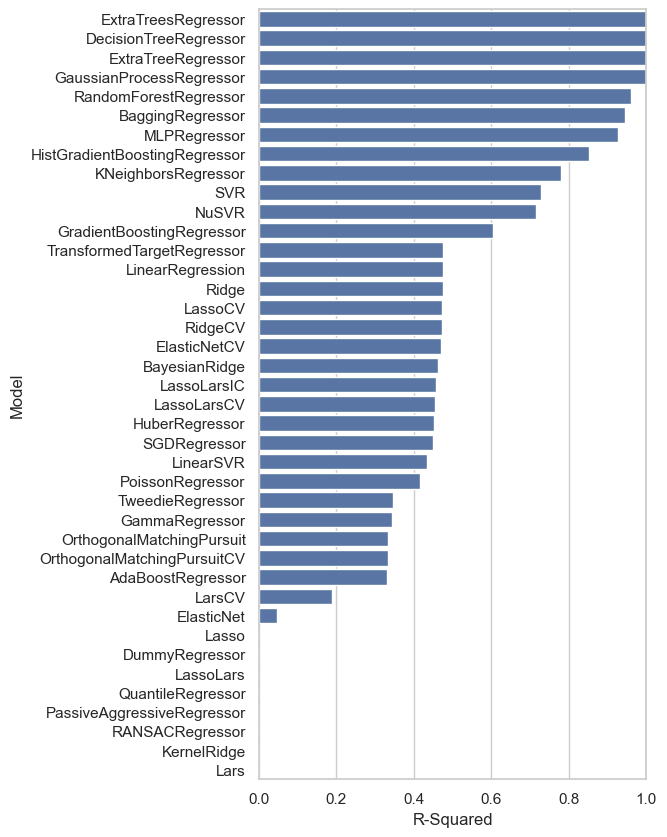

In [377]:
# Bar plot of R-squared values
import matplotlib.pyplot as plt
import seaborn as sns

#train["R-Squared"] = [0 if i < 0 else i for i in train.iloc[:,0] ]

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="R-Squared", data=models_train)
ax.set(xlim=(0, 1))

[(0.0, 10.0)]

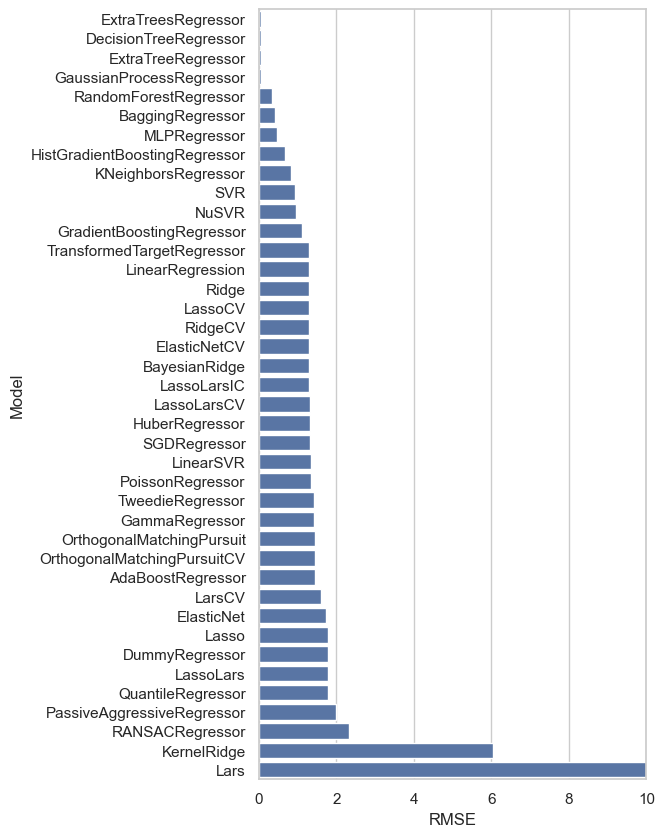

In [378]:
# Bar plot of RMSE values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="RMSE", data=models_train)
ax.set(xlim=(0, 10))

[(0.0, 10.0)]

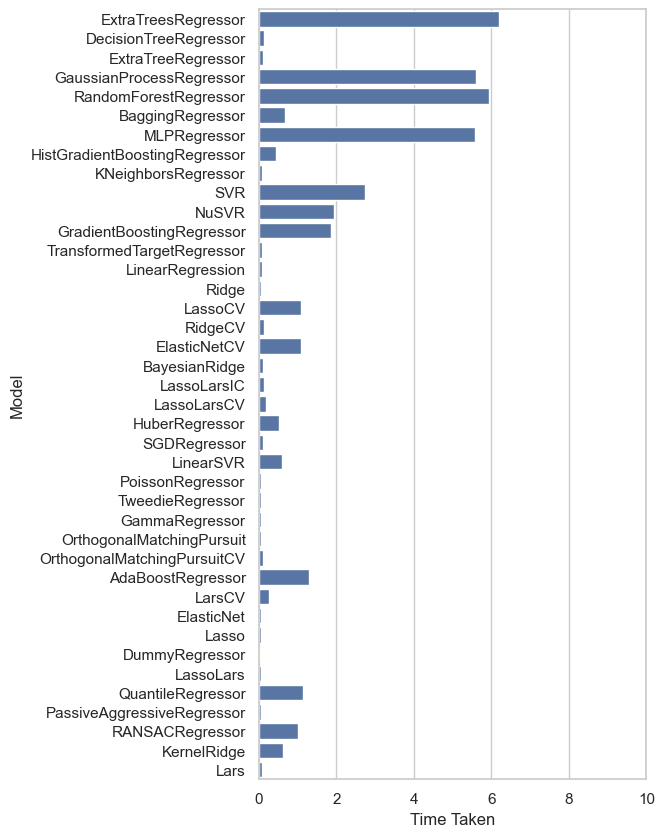

In [379]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_train.index, x="Time Taken", data=models_train)
ax.set(xlim=(0, 10))

[(0.0, 1.0)]

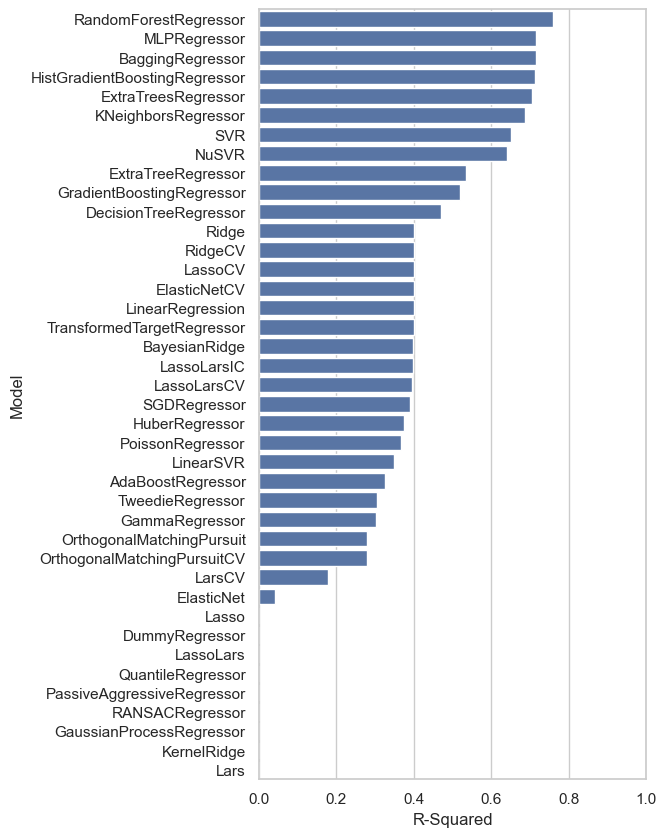

In [380]:
# Bar plot of calculation time
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 10))
sns.set_theme(style="whitegrid")
ax = sns.barplot(y=models_test.index, x="R-Squared", data=models_test)
ax.set(xlim=(0, 1))

### **5. Interprétation et choix du modèle**

Modèle Choisi : **RandomForestRegressor**

- Adjusted R-Squared   **0.716**

- R-Squared            **0.759**

- RMSE                 **0.880**

- Time Taken           **6.039**

### **6. Exportation du modèle**

In [382]:
import joblib

joblib.dump(clf, 'best_pIC50_model.pkl')
joblib.dump(selection, 'variance_selector.pkl') 

print("Model and Selector exported successfully!")

Model and Selector exported successfully!
